# House Price prediction Model

Linear regression model from scrach 

### Problem statement

the training dataset contains three examples with four features (size, bedrooms, floors and, age) shown in the table below.  Note that,size is in sqft rather than 1000 sqft. This causes an issue, which you will solve in the next lab!


| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  


You will build a linear regression model using these values so you can then predict the price for other houses. For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.  

- n = 4 ( no of features selected, j is the jth feature, used in subscript )
- m = 3 ( no of training examples , i is the ith training example, used in superscript )

### parameters to learn, same as no of features + 1
-  w = [ w1,w2,w3,w4 ] 
-  b 


### import packages

In [65]:
import numpy as np
import pandas as pd
import copy, math
import matplotlib.pyplot as plt

### Create a Training dataset

In [66]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [67]:
# data is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


### Parameter initalization

In [68]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


### Single prediction vector will be used with final w, b parameters and given feature to predict the value

In [69]:
def single_prediction_vector(x,w,b):
    """
    single predict using linear regression. 
    """
    p  = np.dot(x,w) + b
    return p


In [70]:
# get zero row, all columns and used the initialized value to predict the value for given vector. 
single_prediction_vector(X_train[0,:],w_init,b_init)

459.9999976194083

### Compute Cost of the model ( MSE Error ) 

In [71]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
      
    """
    
    
    m = X.shape[0]
    cost = 0
    
    for i in range(m):
        y_hat = np.dot(X[i],w ) + b
        y_actual = y[i]
        cost = cost + ( y_hat - y_actual ) ** 2
    cost = cost/(2*m)        
    return cost

In [72]:
total_cost = compute_cost(X_train, y_train, w_init, b_init)

In [73]:
total_cost

1.5578904428966628e-12

<a name="toc_15456_5"></a>
### 5 Gradient Descent With Multiple Variable



Gradient descent for multiple variables:

$$\begin{align*} 
\text{ repeat until convergence : } \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value

In [84]:
# calculate dj_dw , dj_db

def compute_gradient(X,y,w,b ):
    
    """
    Args: 
    X ( ndarray (m,n)) : Training dataset, with m samples, n features
    y ( ndarray (m,)) : traget values
    w ( ndarray (n,)) : weight parameters
    b ( scalar ) : traget values
    
    Returns:
    dj_dw | derivative of cost function w.r.t to w
    dj_db | derivative of cost function w.r.t to b
    
    """
    
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    
    for i in range(m):    
        y_hat = np.dot(X[i],w) + b 
        error = y_hat - y[i]
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + error * X[i, j]  
        
        # dj_dw =  dj_dw + np.dot(error,X[i])
        dj_db = dj_db + error
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw,dj_db    

In [85]:
#Compute and display gradient 
tmp_dj_dw,tmp_dj_db = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -1.6739251501955248e-06
dj_dw at initial w,b: 
 [-2.72623577e-03 -6.27197263e-06 -2.21745578e-06 -6.92403391e-05]


<a name="toc_15456_5"></a>
### 5 Gradient Descent With Multiple Variables

In [96]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Perform gradient descent to learn w and b. updates w and b by taking num_iters gradient steps with learning rate alpha
    X (ndarray (m,n) : m no of training samples, n : no of features
    y (ndarray (m,) :  Target variable
    w_in : initialize weights parameter
    b_in : initialize intercept parameter
    cost_function 
    gradient_function, 
    alpha : learning rate
    num_iters : no of teration you want to perform before convergence. 
    
    return 
    iteration_cost (ndarray (num_iters,) : 
    w_final ( ndarray (n ,) : final weight parameter
    b_final (scalar ) : final intercept parameter
    """
    
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    j_history = list() 
    
    for i in range(num_iters):
        
        dj_dw , dj_db = gradient_function(X,y,w,b)
 
        # update the parameter
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # add itteration cost
        if i <100000:
            j_history.append(cost_function(X,y,w,b))
        
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {j_history[-1]:8.2f}")
            
    return w,b, j_history

In [97]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# print(initial_w)
# some gradient descent settings
iterations = 1000
alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,compute_cost, compute_gradient,  alpha, iterations)
                                                   
                                                    
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost  2529.46
Iteration  100: Cost   695.99
Iteration  200: Cost   694.92
Iteration  300: Cost   693.86
Iteration  400: Cost   692.81
Iteration  500: Cost   691.77
Iteration  600: Cost   690.73
Iteration  700: Cost   689.71
Iteration  800: Cost   688.70
Iteration  900: Cost   687.69
b,w found by gradient descent: -0.00,[ 0.20396569  0.00374919 -0.0112487  -0.0658614 ] 
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


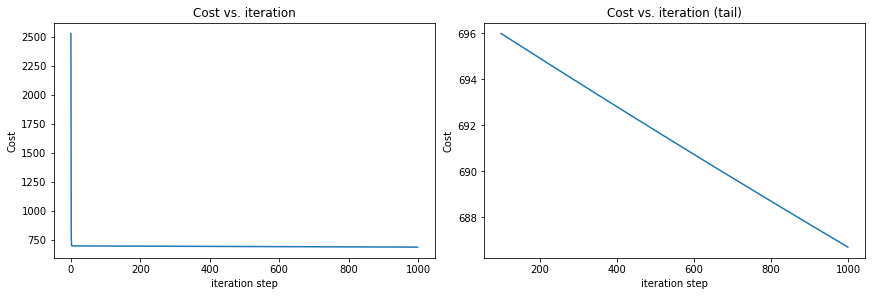

In [98]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()